# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**ResNet-18 Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a ResNet-18 model on the Pneumonia dataset without data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [2]:
# Import utility libraries
import sys
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.resnet_utils import build_resnet18, DropoutRateScheduler
from utils.train_utils import get_callbacks, train_model
from utils.eval_utils import evaluate_model, compare_models
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix

# Imports fo csv storage
import csv
import os
from datetime import datetime
import time

# Core Variables

In [7]:
# Global variables
DATA_PATH = '../data/'
MODEL_PATH = '../models/'
MODEL_NAME = 'resnet_18' # Name of the model to be saved

# Training parameters
BATCH_SIZE = 32 # + 64 and 128
EPOCHS = 10
LEARNING_RATE = 0.001
DROPOUT_RATE = 0.5 # + 0.3 and custom sheduler
DROPOUT_MODE = "fixed" # or custom_scheduler
DROPOUT_RATE_START = 0.5
DROPOUT_RATE_END = 0.3
MODE = 'max'
CHOSEN_METRIC = 'val_AUC' # Metric to be used for model selection, e.g. 'val_loss', 'val_AUC', 'val_accuracy'

FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_pneumonia_model.keras'

# Data Loading & Preprocessing

In [8]:
train_images, train_labels, test_images, test_labels, val_images, val_labels = load_and_preprocess_data(DATA_PATH)


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)


# ResNet-18 Model

## Creation & Compilation

In [9]:
# Create and compile model
model = build_resnet18(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

I0000 00:00:1744289951.129991    7015 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3490 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1050 Ti with Max-Q Design, pci bus id: 0000:01:00.0, compute capability: 6.1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 28, 28,    │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn1                 │ (None, 28, 28,    │        256 │ conv1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu1 (Activation)  │ (None, 28, 28,    │          0 │ bn1[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ maxpool1            │ (None, 14, 14,    │          0 │ relu1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv1 │ (None, 14, 14,    │     36,928 │ maxpool1[0][0]    │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn1   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu1 │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_bn2   │ (None, 14, 14,    │        256 │ stage1_block1_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_add   │ (None, 14, 14,    │          0 │ stage1_block1_bn… │
│ (Add)               │ 64)               │            │ maxpool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block1_relu2 │ (None, 14, 14,    │          0 │ stage1_block1_ad… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv1 │ (None, 14, 14,    │     36,928 │ stage1_block1_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn1   │ (None, 14, 14,    │        256 │ stage1_block2_co… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_relu1 │ (None, 14, 14,    │          0 │ stage1_block2_bn… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_conv2 │ (None, 14, 14,    │     36,928 │ stage1_block2_re… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stage1_block2_bn2   │ (None, 14, 14,    │        256 │ stage1_block2_co

 Total params: 11,183,106 (42.66 MB)

 Trainable params: 11,173,506 (42.62 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [10]:
# dropout_scheduler = DropoutRateScheduler(dropout_start=DROPOUT_RATE_START, dropout_end=DROPOUT_RATE_END, epochs=EPOCHS)

## Training

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - AUC: 0.9913 - accuracy: 0.9513 - loss: 0.1198 - val_AUC: 0.7849 - val_accuracy: 0.7443 - val_loss: 1.8109
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - AUC: 0.9921 - accuracy: 0.9678 - loss: 0.0946 - val_AUC: 0.9951 - val_accuracy: 0.9618 - val_loss: 0.0902
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - AUC: 0.9953 - accuracy: 0.9684 - loss: 0.0860 - val_AUC: 0.9918 - val_accuracy: 0.9599 - val_loss: 0.1142
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - AUC: 0.9973 - accuracy: 0.9757 - loss: 0.0642 - val_AUC: 0.9871 - val_accuracy: 0.9542 - val_loss: 0.1474
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - AUC: 0.9977 - accuracy: 0.9804 - loss: 0.0573 - val_AUC: 0.9345 - val_accuracy: 0.8626 - val_loss: 0.4742
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - AUC: 0.9973 - accuracy: 0.9784 - loss: 0.0549 - val_AUC: 0.9328 - val_accuracy: 0.8588 - val_loss: 0.5584
Epoch 7/10
148/148 ━━━━━━━━━

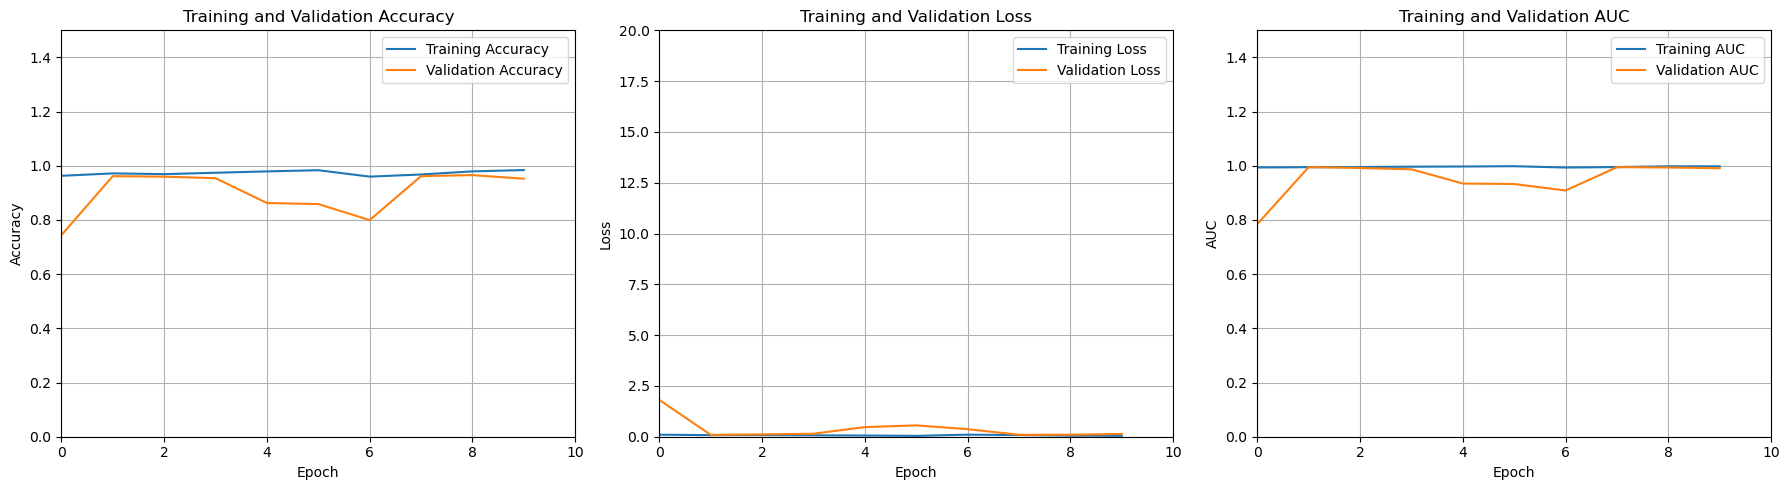

In [12]:
# Train model
start_time = time.time()

history = train_model(
    model, 
    train_images, train_labels,
    val_images, val_labels,
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE
)

exec_time = round(time.time() - start_time, 2)

# Plot training history
plot_training_history(history, epochs=EPOCHS)

# Save final model
model.save(FINAL_MODEL_PATH)

## Evaluation

18/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - AUC: 0.8700 - accuracy: 0.8328 - loss: 1.0445

2025-04-10 14:02:11.548369: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{} for conv %cudnn-conv-bias-activation.63 = (f32[16,64,14,14]{3,2,1,0}, u8[0]{0}) custom-call(f32[16,64,14,14]{3,2,1,0} %bitcast.2421, f32[64,64,3,3]{3,2,1,0} %bitcast.2428, f32[64]{0} %bitcast.2430), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/stage1_block1_conv1_1/convolution" source_file="/home/rafaela/anaconda3/lib/python3.12/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kNone","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-04-10 14:02:11.776439: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Om

20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - AUC: 0.8724 - accuracy: 0.8322 - loss: 1.0257
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step


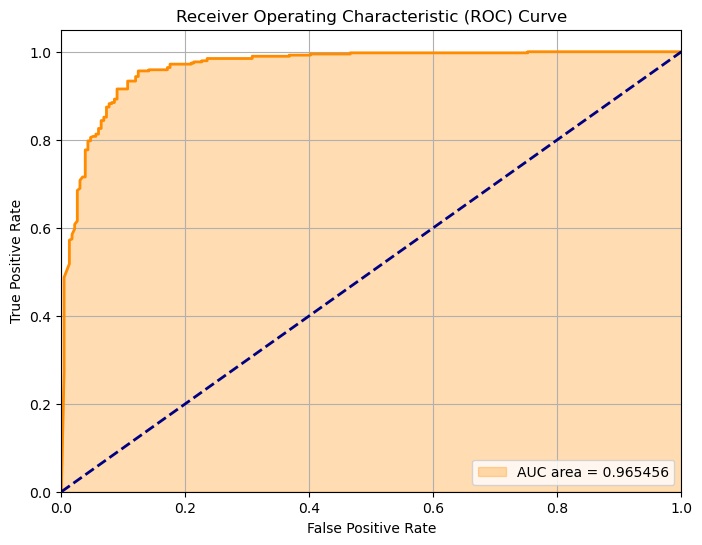

ROC AUC Score: 0.9655


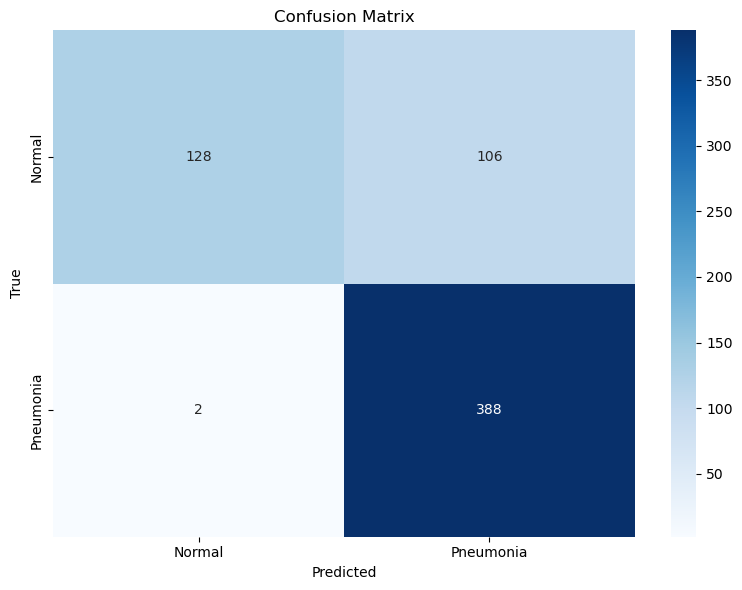

              precision    recall  f1-score   support

      Normal       0.98      0.55      0.70       234
   Pneumonia       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.86      0.83      0.81       624



In [13]:
# Evaluate model
results = evaluate_model(model, test_images, test_labels)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

### Csv to store models and metrics information

In [26]:
model = MODEL_NAME
learning_rate = LEARNING_RATE
num_epochs = EPOCHS
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_auc = history.history['AUC']
val_auc = history.history['val_AUC']
test_loss = results['test_loss']
test_acc = results['test_accuracy']
test_auc = results['test_auc']
results_roc_fpr = results['roc']['fpr']
results_roc_tpr = results['roc']['tpr']
results_roc_auc = results['roc']['auc']
results_classification_report = results['classification_report']

if DROPOUT_MODE == "fixed":
    dropout_mode = "fixed"
    dropout_value = DROPOUT_RATE
    dropout_start = ""
    dropout_end = ""
else:
    dropout_mode = "custom_scheduler"
    dropout_start = DROPOUT_RATE_START
    dropout_end = DROPOUT_RATE_END
    dropout_value = ""

models_info = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_name": model,
    "learning_rate": learning_rate,
    "dropout_mode" : dropout_mode,
    "dropout": dropout_value,
    "dropout_start": dropout_start,
    "dropout_end": dropout_end,
    "epochs": num_epochs,
    "train_loss": train_loss,
    "val_loss": val_loss,
    "train_acc": train_acc,
    "val_acc": val_acc,
    "train_auc" : train_auc,
    "val_auc" : val_auc,
    "test_loss": test_loss,
    "test_acc": test_acc,
    "test_auc" : test_auc,
    "roc_fpr" : results_roc_fpr,
    "roc_tpr" : results_roc_tpr,
    "roc_auc_area" : results_roc_auc,
    "classification_report" : results_classification_report,
    "exec_time": exec_time
}

csv_path = "models_info.csv"
file_exists = os.path.isfile(csv_path)

with open(csv_path, mode="a", newline="") as file:
    writer = csv.DictWriter(file, fieldnames=models_info.keys())
    if not file_exists:
        writer.writeheader()
    writer.writerow(models_info)

print(f"Csv stored at {csv_path}")

Csv stored at models_info.csv
